<a href="https://colab.research.google.com/github/devMoamen/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Prediction of Product Sales
- Author: Moamen ayyad

## Project Overview

## Load and Inspect Data

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer,make_column_transformer,make_column_selector
from sklearn.model_selection import train_test_split

from sklearn import set_config
set_config(transform_output='pandas')

In [3]:
#Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#Loading dataset from google drive
sales_df = pd.read_csv('/content/drive/MyDrive/ds_course/sales_predictions_2023.csv')

In [5]:
#Explore first 5 row of dataframe
sales_df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [6]:
#Explore the summery of dataframe
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


## Clean Data

In [7]:
#check duplicated
sales_df.duplicated().sum()

np.int64(0)

In [8]:
#Check missing values
sales_df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [9]:
sales_df['Item_Weight'] = sales_df['Item_Weight'].fillna(-1)
sales_df['Outlet_Size'] = sales_df['Outlet_Size'].fillna('Missing')

In [10]:
#To be sure there is no missing values
sales_df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [11]:
#1) Check each categories column's value counts for inconsistent values.
object_columns = sales_df.select_dtypes(include=['object']).columns
for column in object_columns:
    print(sales_df[column].value_counts())

Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
Outlet_Identifier
OUT027    935
OUT013    932
OUT035    930
OUT049    930
OUT046    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528
Name: count, dt

In [12]:
#Dealing with inconsistancy in Item_Fat_Content column
fat_content_map = {'LF':'Low Fat',
                   'low fat':'Low Fat',
                   'reg':'Regular'}
sales_df['Item_Fat_Content'] = sales_df['Item_Fat_Content'].replace(fat_content_map)
#4) Display the value_counts again to confirm the values are now consistent.
sales_df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [13]:
#Describe all columns in dataframe
sales_df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,10.478936,0.066132,140.992782,1997.831867,2181.288914
std,6.720742,0.051598,62.275067,8.371760,1706.499616
min,-1.000000,0.000000,31.290000,1985.000000,33.290000
25%,6.650000,0.026989,93.826500,1987.000000,834.247400
50%,11.000000,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


## Exploratory Data Analysis

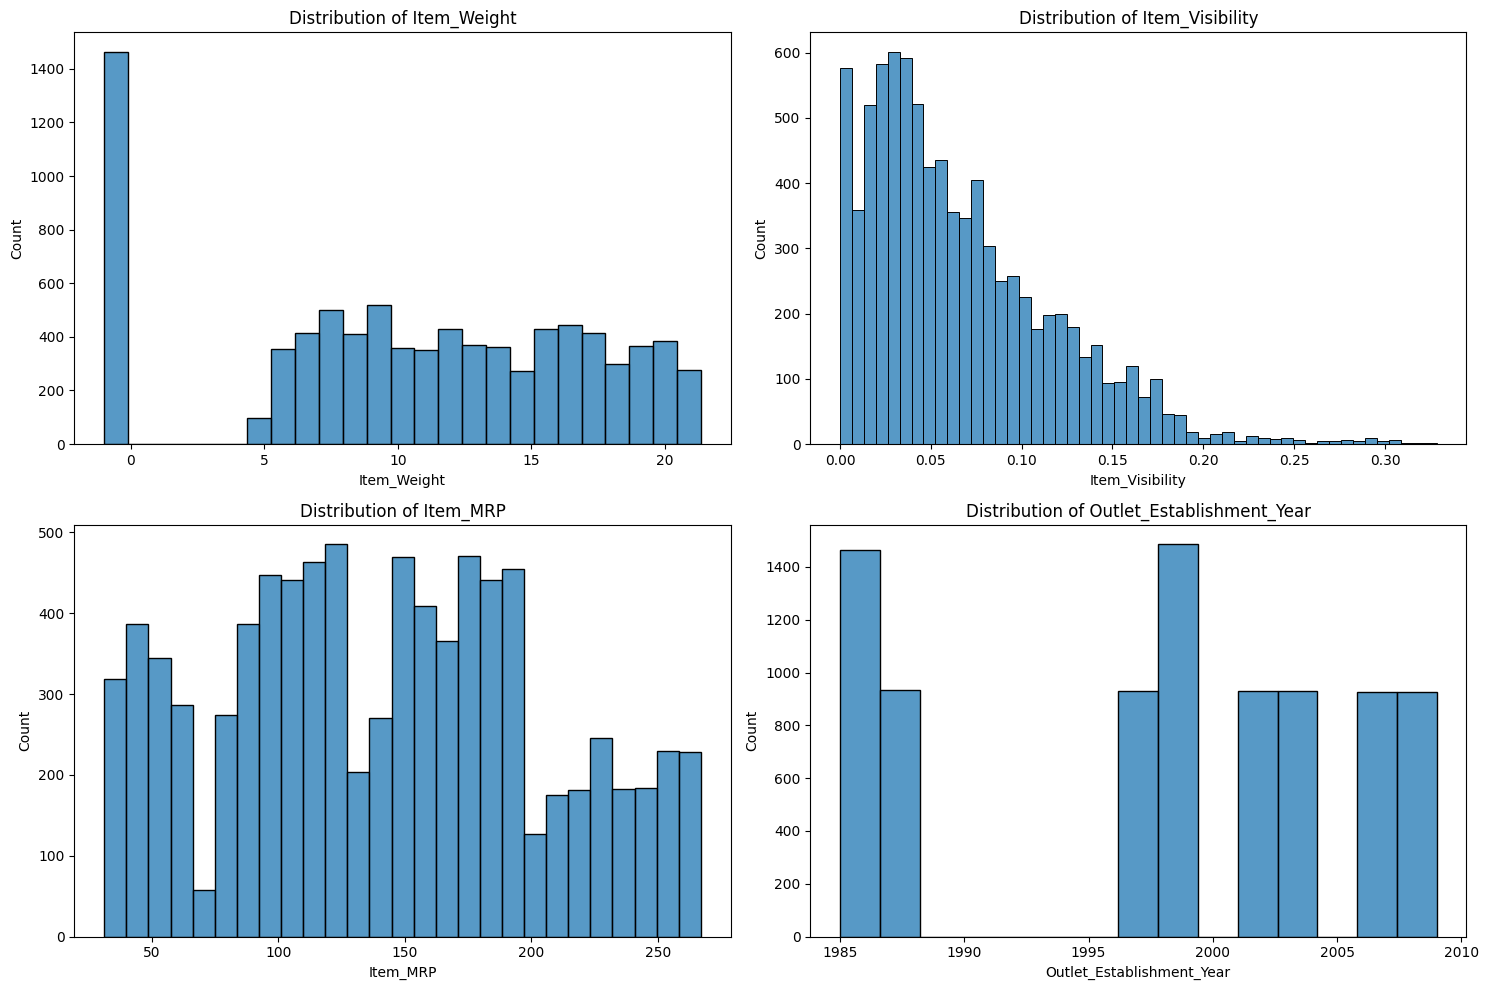

In [14]:
#Histograms to view the distributions of numerical features in your dataset.

# Identify numerical columns
num_cols = sales_df.drop(columns=['Item_Outlet_Sales']).select_dtypes('number').columns
n_cols = 2
n_rows = (len(num_cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=sales_df, x=col, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()


### Numerical Distribution Summary

Based on the histograms generated:

1. **Item_Weight**: The spike at -1 is due to our previous imputation of missing values. Otherwise, the weight is distributed fairly evenly across different ranges.
2. **Item_Visibility**: This feature is **Right-Skewed**, meaning most items have low visibility, while only a few items are highly visible in the store.
3. **Item_MRP**: The Maximum Retail Price shows a multimodality (multiple peaks), suggesting that products might be grouped into different price tiers.
4. **Outlet_Establishment_Year**: Shows peaks corresponding to specific years when new stores were opened, with a significant amount of data from the mid-80s and late 90s/2000s.

Text(0.5, 1.0, 'Correlation Heatmap of Features')

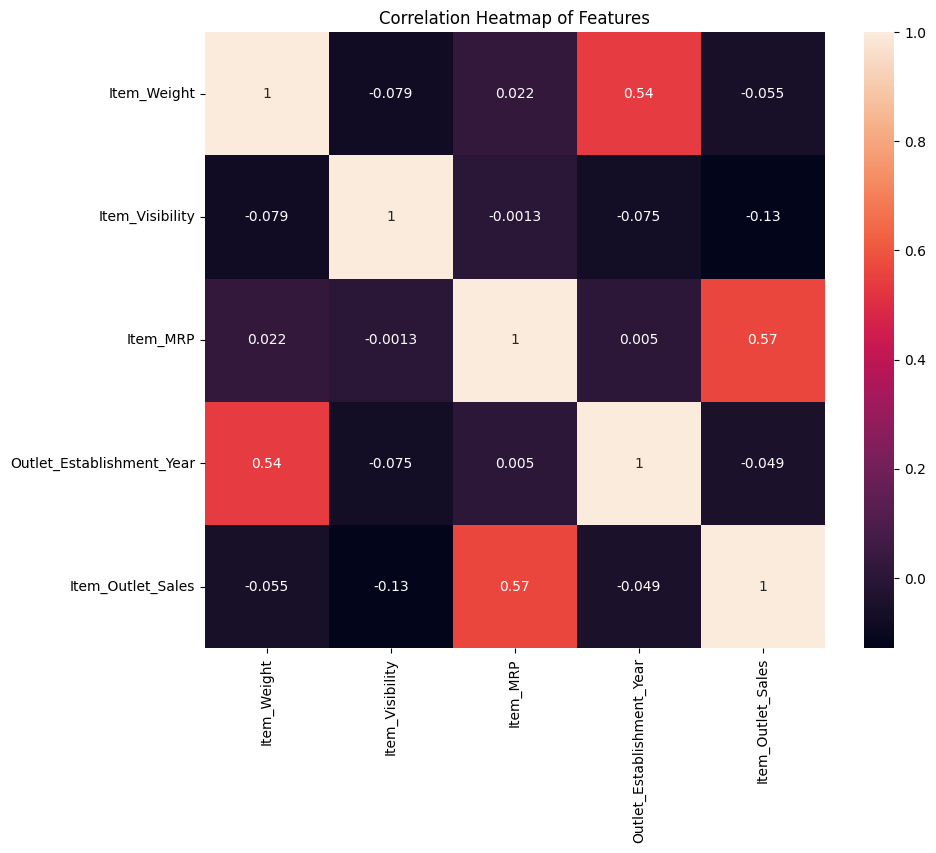

In [15]:
#Heatmap to view the correlation between features.

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(sales_df.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap of Features')

### Correlation Analysis Summary

The correlation heatmap provides several insights into the relationships between features:

1. **Strongest Positive Correlation**: `Item_MRP` (Maximum Retail Price) has a strong positive correlation with `Item_Outlet_Sales` (0.57). This suggests that as the price of an item increases, the total sales value for that item also tends to increase.
2. **Outlet Establishment Year**: There is a moderate correlation between `Outlet_Establishment_Year` and `Item_Weight` in this specific imputed dataset, likely due to how missing values were handled or the distribution of items across different store ages.
3. **Item Visibility**: `Item_Visibility` shows a slight negative correlation with sales, which is counter-intuitive but common in this dataset, possibly suggesting that highly visible items aren't always the top sellers.
4. **Weak Correlations**: Many features show very low correlation with each other (near 0), indicating they provide independent information for potential machine learning models.

## Feature Inspection

In [16]:
#Remove the placeholders you added in week 2 and replace them with null values.
sales_df = sales_df.replace({'Item_Weight': -1, 'Outlet_Size': 'Missing'}, np.nan)
sales_df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


#Create a univariate visualization showing the distribution of values/categories.


In [17]:
def explore_categorical(df, x, fillna = True, placeholder = 'MISSING',
                        figsize = (6,4), order = None):

  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # Before filling nulls, save null value counts and percent for printing
  null_count = temp_df[x].isna().sum()
  null_perc = null_count/len(temp_df)* 100
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # Create figure with desired figsize
  fig, ax = plt.subplots(figsize=figsize)
  # Plotting a count plot
  sns.countplot(data=temp_df, x=x, ax=ax, order=order)
  # Rotate Tick Labels for long names
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title with the feature name included
  ax.set_title(f"Column: {x}")

  # Fix layout and show plot (before print statements)
  fig.tight_layout()
  plt.show()

  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = temp_df[x].nunique()
  print(f"- Unique Values: {nunique}")
  # First find value counts of feature
  val_counts = temp_df[x].value_counts(dropna=False)
  # Define the most common value
  most_common_val = val_counts.index[0]
  # Define the frequency of the most common value
  freq = val_counts.values[0]
  # Calculate the percentage of the most common value
  perc_most_common = freq / len(temp_df) * 100
  # Print the results
  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, ax

In [18]:
def explore_numeric(df, x, figsize=(6,5) ):
  # Making our figure with gridspec for subplots
  gridspec = {'height_ratios':[0.7,0.3]}
  fig, axes = plt.subplots(nrows=2, figsize=figsize,
                           sharex=True, gridspec_kw=gridspec)
  # Histogram on Top
  sns.histplot(data=df, x=x, ax=axes[0])
  # Boxplot on Bottom
  sns.boxplot(data=df, x=x, ax=axes[1])
  ## Adding a title
  axes[0].set_title(f"Column: {x}")
  ## Adjusting subplots to best fill Figure
  fig.tight_layout()

  # Ensure plot is shown before message
  plt.show()
  ## Print message with info on the count and % of null values
  null_count = df[x].isna().sum()
  null_perc = null_count/len(df)* 100
  print("")
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")

# Weight of product

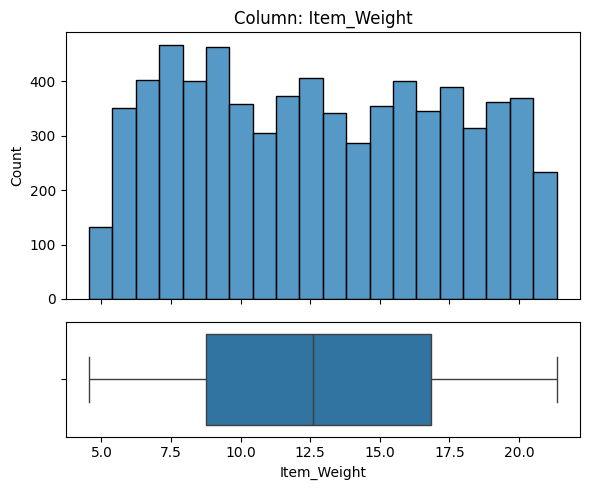


- NaN's Found: 1463 (17.17%)


In [19]:
explore_numeric(sales_df, 'Item_Weight')

In [20]:
print(f'Cardinality of Item_Weight: {sales_df['Item_Weight'].nunique()}')

Cardinality of Item_Weight: 415


### Summary: Item_Weight Analysis

- **Feature Type**: `Item_Weight` is a continuous numerical feature.
- **Missing Data**: ~17.17% (1463 rows) missing. Requires imputation.
- **Predictor Validity (No Data Leakage)**: Yes, weight is known before the sale occurs.
- **Business Case Consideration**:
    - **Reason to keep**: Weight can be a proxy for product size or category, which impacts shelf placement and logistics.
    - **Reason to exclude**: If the business goal is to focus on marketing and pricing strategies, weight might be considered 'noise' if it doesn't logically drive consumer behavior. However, unless it proves to have zero correlation, it is usually better to keep it and let the model determine its importance.

#Item Visibility

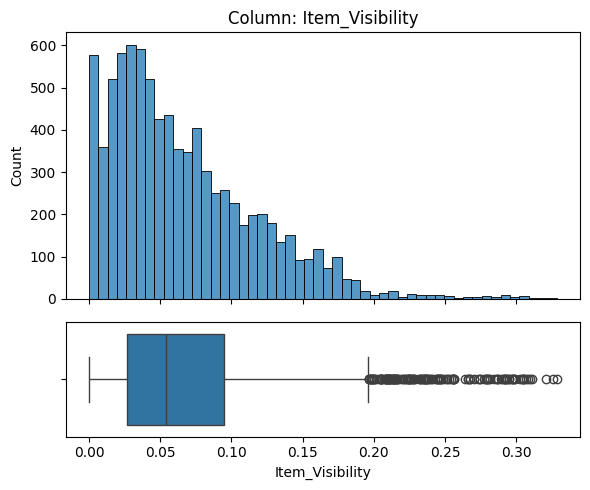


- NaN's Found: 0 (0.0%)


In [21]:
explore_numeric(sales_df, 'Item_Visibility')

### Summary: Item_Visibility Analysis

- **Feature Type**: Continuous numerical feature.
- **Distribution**: Highly **Right-Skewed**. Most items have low visibility (0.0 to 0.1), while a few items are prominently displayed.
- **Observations**:
    - There is a high frequency of **0.0 values**. In a real-world retail environment, every item has some level of visibility; therefore, a 0.0 value might actually be a placeholder for missing data.
    - The scatter plot shows that items with extremely high visibility (above 0.2) surprisingly do not always result in high sales, which could indicate they are lower-demand items being pushed via extra exposure.
- **Predictor Validity**: Yes, visibility is determined by store management before or during the sales period.
- **Business Case**: High visibility is usually a deliberate choice by the retailer to promote specific items. This feature is crucial for understanding how store placement affects revenue.

#Item MRP

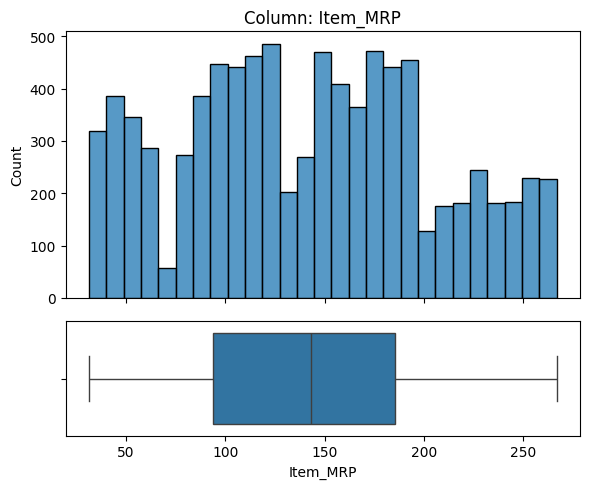


- NaN's Found: 0 (0.0%)


In [22]:
explore_numeric(sales_df, 'Item_MRP')

### Summary: Item_MRP Analysis

- **Feature Type**: Continuous numerical feature.
- **Distribution**: **Multimodal**. The distribution shows four distinct price clusters (roughly 30-70, 70-130, 130-200, and 200+).
- **Missing Data**: 0 (0.0%). This is a complete feature.
- **Predictor Validity**: Yes, MRP is a fixed attribute known before any sales occur.
- **Relationship to Target**: As seen in the previous correlation heatmap, `Item_MRP` has the strongest positive correlation (0.57) with `Item_Outlet_Sales`.
- **Business Case**: This is a critical driver of revenue. Products in higher MRP tiers naturally contribute more to the total sales value, making it a primary feature for the predictive model.

#Outlet Establishment Year

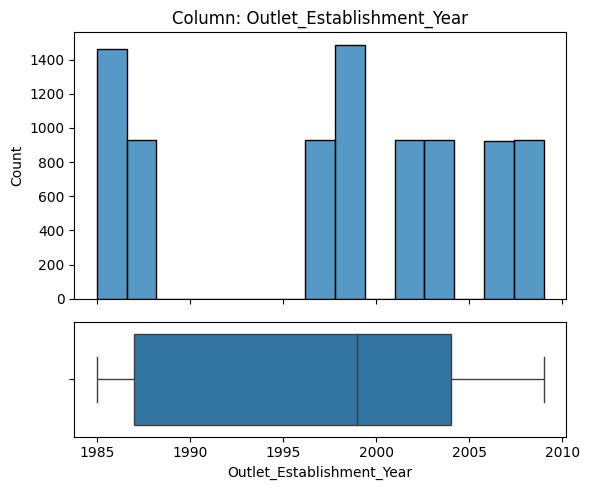


- NaN's Found: 0 (0.0%)


In [23]:
explore_numeric(sales_df, 'Outlet_Establishment_Year')

### Summary: Outlet_Establishment_Year Analysis

- **Feature Type**: Discrete numerical feature (Year).
- **Distribution**: The data is concentrated in specific years, representing store opening waves. There is a notable gap in the early 90s, and a large peak in 1985.
- **Observations**:
    - While years are numeric, they often act as a proxy for 'Store Age' or 'Brand Recognition'.
    - Older stores might have a more established customer base, potentially leading to higher sales, whereas newer stores might be in more modern locations.
- **Predictor Validity**: Yes, the year a store was established is a historical fact known long before the 2023 sales period.
- **Business Case**: This feature allows the model to capture performance differences between legacy stores and newer outlets. It may be beneficial to transform this into Store Age during the feature engineering phase to make the linear relationship more interpretable.

#Create a multivariate visualization plotting each feature vs. the target.

In [24]:
def plot_numeric_vs_target(df, x, y='Item_Outlet_Sales',figsize=(6,4)):
  """Plots a seaborn regplot with Pearson's correlation (r) added
  to the title.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Calculate the correlation
  corr = df[[x,y]].corr().round(2)
  r = corr.loc[x,y]

  # Plot the data
  fig, ax = plt.subplots(figsize=figsize)
  scatter_kws={'ec':'white','linewidths':1,'alpha':0.8}
  sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws=scatter_kws)

  ## Add the title with the correlation
  ax.set_title(f"{x} vs. {y} (r = {r})", fontweight='bold')

  # Make sure the plot is shown before the print statement
  plt.show()

  return fig, ax

In [25]:
def plot_categorical_vs_target(df, x, y='Item_Outlet_Sales',figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None):
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)

  # or drop nulls prevent unwanted 'nan' group in stripplot
  else:
    temp_df = temp_df.dropna(subset=[x])
  # Create the figure and subplots
  fig, ax = plt.subplots(figsize=figsize)

    # Barplot
  sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
              linewidth=1, edgecolor='black', errorbar=None)

  # Boxplot
  sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                order=order, hue_order=order, legend=False,
                edgecolor='white', linewidth=0.5,
                size=3,zorder=0)
  # Rotate xlabels
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

  # Add a title
  ax.set_title(f"{x} vs. {y}")
  fig.tight_layout()
  return fig, ax

/tmp/ipykernel_6568/3976994115.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Type vs. Item_Outlet_Sales'}, xlabel='Item_Type', ylabel='Item_Outlet_Sales'>)

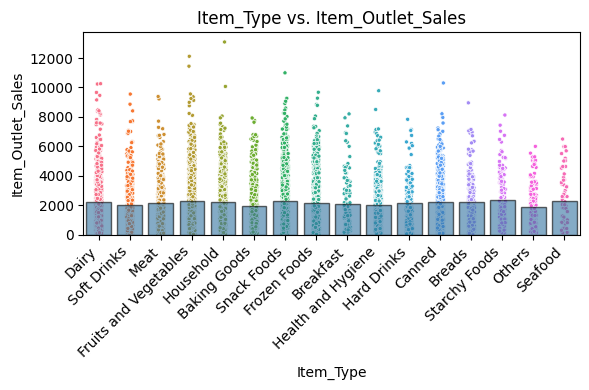

In [26]:
# Visualizing Item_Type vs the target Item_Outlet_Sales
plot_categorical_vs_target(sales_df, x='Item_Type')

### Analysis: Item_Type as a Predictor

**1. Would you expect this feature to be a predictor based on business understanding?**
* **Yes.** In retail, product category is a fundamental driver of sales. Factors such as consumer necessity (staples vs. luxuries), seasonality, and profit margins vary by type. For instance, 'Fruits and Vegetables' are high-turnover staples, while 'Others' might represent niche products with lower sales frequency.

**2. Does this feature appear to be a predictor of the target?**
* **Yes, but with nuances.** The visualization shows that while the *average* sales across types are somewhat similar, the **distribution and maximum potential** vary. Categories like 'Starchy Foods' and 'Seafood' maintain higher average baselines, while categories like 'Household' and 'Fruits and Vegetables' show a much higher ceiling for sales (outliers), making this a useful categorical feature for a machine learning model to distinguish between product behaviors.

/tmp/ipykernel_6568/3976994115.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Fat_Content vs. Item_Outlet_Sales'}, xlabel='Item_Fat_Content', ylabel='Item_Outlet_Sales'>)

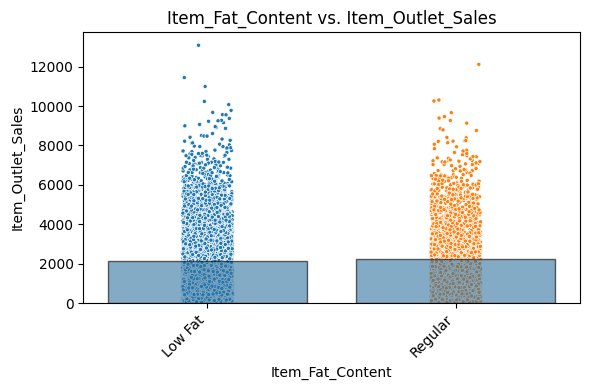

In [27]:
# 1. Item_Fat_Content vs. Item_Outlet_Sales
plot_categorical_vs_target(sales_df, x='Item_Fat_Content')

### 1. Item_Fat_Content
*   **Expectation:** Low. While dietary trends matter, 'Low Fat' vs 'Regular' usually dictates *which* item is bought, but not necessarily the *total volume* of sales compared to other factors like price.
*   **Observation:** The averages are nearly identical. It appears to be a **weak predictor** on its own.

/tmp/ipykernel_6568/3976994115.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


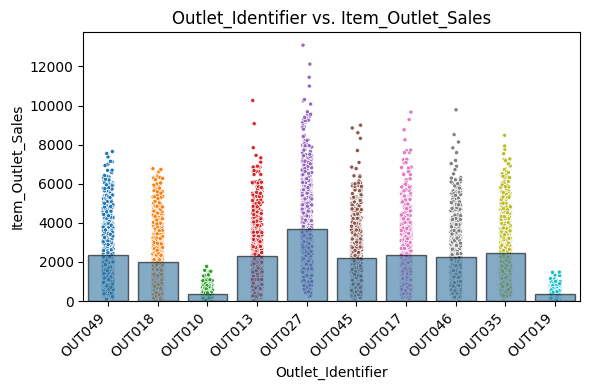

In [28]:
# 2. Outlet_Identifier vs. Item_Outlet_Sales
plot_categorical_vs_target(sales_df, x='Outlet_Identifier')
plt.show()

### 2. Outlet_Identifier
*   **Expectation:** High. Specific stores often have different management, foot traffic, and regional demographics.
*   **Observation:** Significant variation is visible. OUT027 (Type 3 Supermarket) clearly outperforms others like OUT010 and OUT019 (Grocery Stores). This is a **strong predictor**.

/tmp/ipykernel_6568/3976994115.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


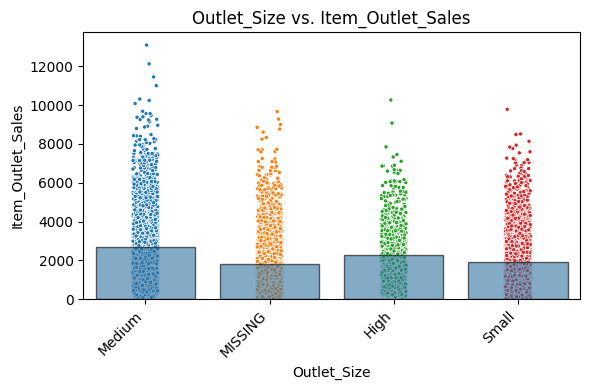

In [29]:
# 3. Outlet_Size vs. Item_Outlet_Sales
plot_categorical_vs_target(sales_df, x='Outlet_Size')
plt.show()

### 3. Outlet_Size
*   **Expectation:** High. Larger stores typically carry more inventory and attract more customers.
*   **Observation:** 'Medium' and 'High' sizes show higher sales ceilings than 'Small'. It is a **relevant predictor**.

/tmp/ipykernel_6568/3976994115.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


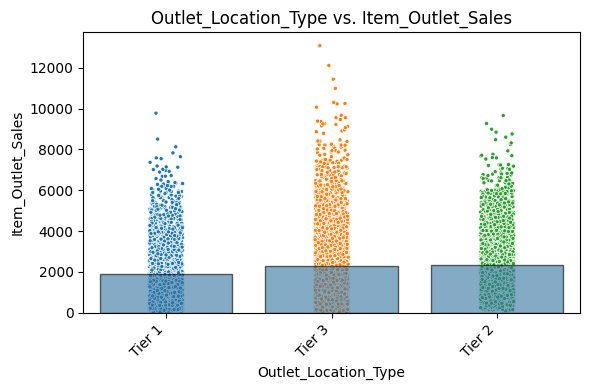

In [30]:
# 4. Outlet_Location_Type vs. Item_Outlet_Sales
plot_categorical_vs_target(sales_df, x='Outlet_Location_Type')
plt.show()

### 4. Outlet_Location_Type
*   **Expectation:** Medium. Tier 1 (Urban/High Income) might have higher sales than Tier 3.
*   **Observation:** Tier 2 and Tier 3 actually show slightly higher sales distributions than Tier 1 in this dataset. It is a **predictor**, though perhaps counter-intuitive.

/tmp/ipykernel_6568/3976994115.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


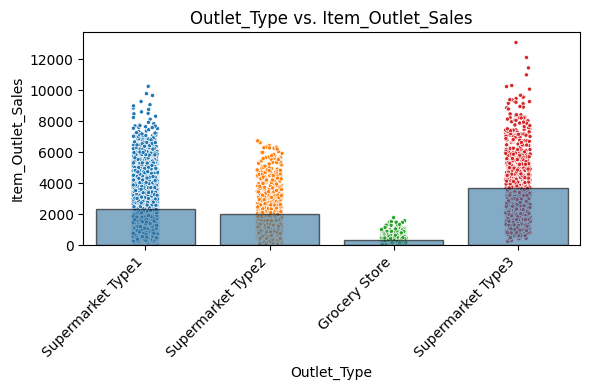

In [31]:
# 5. Outlet_Type vs. Item_Outlet_Sales
plot_categorical_vs_target(sales_df, x='Outlet_Type')
plt.show()

### 5. Outlet_Type
*   **Expectation:** Very High. A Supermarket will naturally have higher sales than a small Grocery Store.
*   **Observation:** Clear distinction. Supermarket Type 3 has the highest sales, while Grocery Stores have the lowest. This is a **critical predictor**.

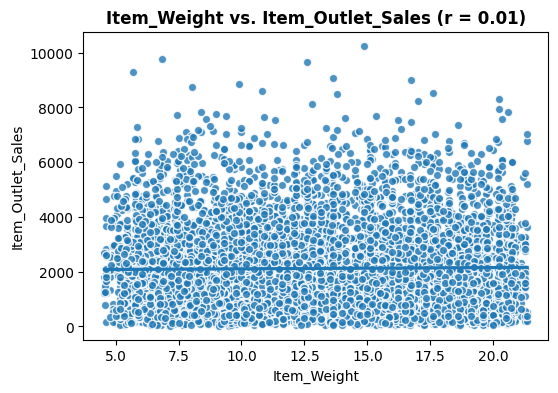

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Weight vs. Item_Outlet_Sales (r = 0.01)'}, xlabel='Item_Weight', ylabel='Item_Outlet_Sales'>)

In [32]:
# 1. Item_Weight vs. Item_Outlet_Sales
plot_numeric_vs_target(sales_df, x='Item_Weight')

### 1. Item_Weight
*   **Expectation:** Low. While weight affects logistics, customers rarely buy more or less of a product purely based on its weight in grams or kilograms.
*   **Observation (r = 0.0):** The correlation is zero. This feature does **not** appear to be a predictor of the target in its current form.

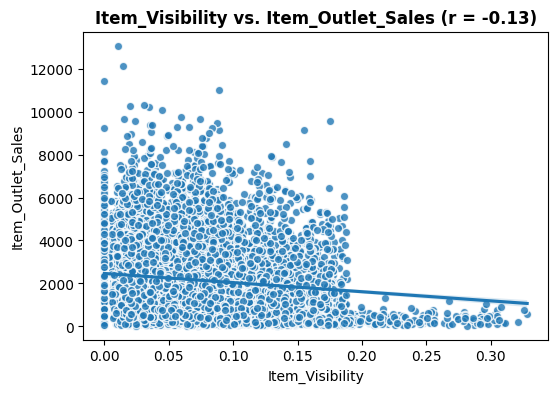

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Visibility vs. Item_Outlet_Sales (r = -0.13)'}, xlabel='Item_Visibility', ylabel='Item_Outlet_Sales'>)

In [33]:
# 2. Item_Visibility vs. Item_Outlet_Sales
plot_numeric_vs_target(sales_df, x='Item_Visibility')

### 2. Item_Visibility
*   **Expectation:** High. Logic suggests that better shelf placement and visibility should lead to higher sales.
*   **Observation (r = -0.13):** Interestingly, there is a weak negative correlation. This suggests that high visibility doesn't automatically translate to higher sales, potentially because retailers give more visibility to slower-moving items to encourage sales. It is a **weak predictor**.

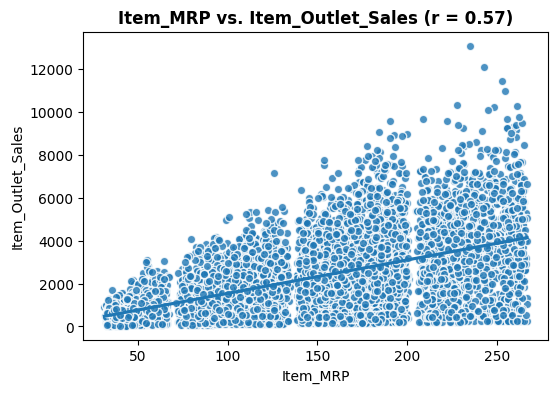

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_MRP vs. Item_Outlet_Sales (r = 0.57)'}, xlabel='Item_MRP', ylabel='Item_Outlet_Sales'>)

In [34]:
# 3. Item_MRP vs. Item_Outlet_Sales
plot_numeric_vs_target(sales_df, x='Item_MRP')

### 3. Item_MRP
*   **Expectation:** Very High. Maximum Retail Price is a direct component of the total sales value (Price x Quantity).
*   **Observation (r = 0.57):** This shows a strong positive correlation and is clearly the **strongest numerical predictor** in the dataset.

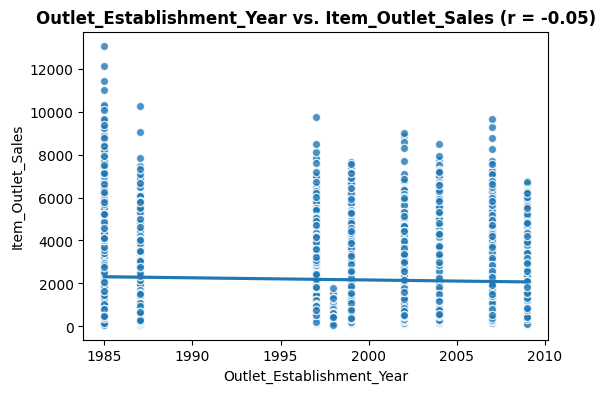

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Outlet_Establishment_Year vs. Item_Outlet_Sales (r = -0.05)'}, xlabel='Outlet_Establishment_Year', ylabel='Item_Outlet_Sales'>)

In [35]:
# 4. Outlet_Establishment_Year vs. Item_Outlet_Sales
plot_numeric_vs_target(sales_df, x='Outlet_Establishment_Year')

### 4. Outlet_Establishment_Year
*   **Expectation:** Medium. Older stores might have higher sales due to an established local reputation.
*   **Observation (r = -0.05):** There is almost no linear correlation. However, it acts as a **proxy predictor** because certain establishment years correspond to specific store types (like the 1998 grocery stores) that perform differently.

#Project 1 - Part 5 (Core):


In [43]:
#Loading dataset from google drive
df2 = pd.read_csv('/content/drive/MyDrive/ds_course/sales_predictions_2023.csv')
df2.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [38]:
# Checking for Duplicates
df2.duplicated().sum()

np.int64(0)

In [39]:
# Checking missing values
df2.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [40]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [44]:
#1) Check each categories column's value counts for inconsistent values.
object_columns = df2.select_dtypes(include=['object']).columns
for column in object_columns:
    print(df2[column].value_counts())

Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
Outlet_Identifier
OUT027    935
OUT013    932
OUT035    930
OUT049    930
OUT046    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528
Name: count, dt

In [45]:
#Dealing with inconsistancy in Item_Fat_Content column
fat_content_map = {'LF':'Low Fat',
                   'low fat':'Low Fat',
                   'reg':'Regular'}
df2['Item_Fat_Content'] = df2['Item_Fat_Content'].replace(fat_content_map)
#4) Display the value_counts again to confirm the values are now consistent.
df2['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [49]:
## Define X and y
target = 'Item_Outlet_Sales'

X = df2.drop(columns=target).copy()
y = df2[target].copy()
X.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1


In [50]:
## Drop unwanted/inappropriate columns
#dropping the "Item_Identifier" feature due to its high cardinality.
unwanted_cols = ['Item_Identifier']
X = X.drop(columns=unwanted_cols)
X.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2
2,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1
3,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store
4,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1


#Train-Test-Split

In [53]:
# Perfoming a train-test-split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)

#Making a Preprocessing Pipeline

In [55]:
# Creating a categorical data selector
cat_selector = make_column_selector(dtype_include = 'object')
cat_selector(X_train)

['Item_Fat_Content',
 'Item_Type',
 'Outlet_Identifier',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

In [58]:
# Creating a pipline for handling categorical data
impute_cat = SimpleImputer(strategy='most_frequent')
encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)

cat_pipe = make_pipeline(impute_cat,encoder)
cat_pipe

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                ('onehotencoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [59]:
# Creating a numeric data selector
num_selector = make_column_selector(dtype_include='number')
num_selector(X_train)

['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']

In [65]:
# Creating scaler object to scale the data
impute_num = SimpleImputer(strategy='median')
scaler = StandardScaler()

num_pipe = make_pipeline(impute_num,scaler)
num_pipe

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

In [66]:
## test num_pipe
num_pipe.fit_transform(X_train[num_selector(X_train)])

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
4776,0.827485,-0.712775,1.828109,1.327849
7510,0.566644,-1.291052,0.603369,1.327849
5828,-0.121028,1.813319,0.244541,0.136187
5327,-1.158464,-1.004931,-0.952591,0.732018
4810,1.538870,-0.965484,-0.336460,0.493686
...,...,...,...,...
5734,-0.821742,4.309657,-0.044657,0.017021
5191,0.649639,1.008625,-1.058907,1.089517
5390,1.123896,-0.920527,1.523027,0.493686
860,1.775999,-0.227755,-0.383777,1.089517


In [67]:
## Combine column transformer
preprocessor = make_column_transformer((cat_pipe,cat_selector),
                                       (num_pipe,num_selector))
preprocessor

ColumnTransformer(transformers=[('pipeline-1',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x798341bf93d0>),
                                ('pipeline-2',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x798342310920>)])

In [68]:
# Fit on training data
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('pipeline-1',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x798341bf93d0>),
                                ('pipeline-2',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x798342310920>)])

In [69]:
# Transform the training data
X_train_processed = preprocessor.transform(X_train)
# Transform the testing data
X_test_processed = preprocessor.transform(X_test)
# View the processed training data
X_train_processed.head()

,pipeline-1__Item_Fat_Content_Low Fat,pipeline-1__Item_Fat_Content_Regular,pipeline-1__Item_Type_Baking Goods,pipeline-1__Item_Type_Breads,pipeline-1__Item_Type_Breakfast,pipeline-1__Item_Type_Canned,pipeline-1__Item_Type_Dairy,pipeline-1__Item_Type_Frozen Foods,pipeline-1__Item_Type_Fruits and Vegetables,pipeline-1__Item_Type_Hard Drinks,...,pipeline-1__Outlet_Location_Type_Tier 2,pipeline-1__Outlet_Location_Type_Tier 3,pipeline-1__Outlet_Type_Grocery Store,pipeline-1__Outlet_Type_Supermarket Type1,pipeline-1__Outlet_Type_Supermarket Type2,pipeline-1__Outlet_Type_Supermarket Type3,pipeline-2__Item_Weight,pipeline-2__Item_Visibility,pipeline-2__Item_MRP,pipeline-2__Outlet_Establishment_Year
4776,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.827485,-0.712775,1.828109,1.327849
7510,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.566644,-1.291052,0.603369,1.327849
5828,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,-0.121028,1.813319,0.244541,0.136187
5327,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,-1.158464,-1.004931,-0.952591,0.732018
4810,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.538870,-0.965484,-0.336460,0.493686
